In [1]:
import sys
sys.path.insert(0, "pythonlib")
import pandas as pd
from enginewash import WashConfig, WashCalculator, FlightRecord, FlightPhase, MaintenanceRecord, EGTHDM

ENGINES = ["657287", "804853"]
START, END = "2025-05-01", "2026-05-01"

maintenance = pd.read_parquet("https://storage.yandexcloud.net/ecm-data/ecmapp.maintenance_20260610.parquet")
takeoff = pd.read_parquet("https://storage.yandexcloud.net/ecm-data/s7.b737_takeoff_20260222-merged.parquet")

takeoff = takeoff[["engine_id", "flight_datetime", "egthdm"]].dropna()
takeoff["engine_id"] = takeoff["engine_id"].astype(int).astype(str)
takeoff = takeoff[
    takeoff["engine_id"].isin(ENGINES)
    & (takeoff["flight_datetime"] >= START)
    & (takeoff["flight_datetime"] <= END)
]

flights = [
    FlightRecord(
        engine_id=row.engine_id,
        flight_datetime=row.flight_datetime,
        parameter_name="EGTHDM",
        flight_phase=FlightPhase.TAKEOFF,
        float_value=row.egthdm,
    )
    for row in takeoff.itertuples()
]

wash = maintenance[
    maintenance["ata_code"].isin(['330', '340', '331'])
    & ~maintenance["deleted"]
    & maintenance["engine_id"].isin(ENGINES) 
    & (maintenance["maint_datetime"] >= START)
    & (maintenance["maint_datetime"] <= END)
]

wash = wash.sort_values("mutation_time").drop_duplicates(["engine_id", "maint_datetime"], keep="first")

maintenance_records = [
    MaintenanceRecord(
        engine_id=row.engine_id,
        maint_datetime=pd.to_datetime(row.maint_datetime),
        ata_code=row.ata_code
    )
    for row in wash.itertuples()
]

calc = WashCalculator(
   WashConfig(smooth_window=15, n_obs_mean=30)
)
summaries = calc.process(flights=flights, maintenances=maintenance_records, utilizations=[], parameter=EGTHDM)

result = pd.DataFrame([
    {
        "engine_id": ev.engine_id,
        "event_index": ev.event_index,
        "maint_date": ev.maint_datetime,
        "ata_code": ev.ata_code,
        "mean_before": round(ev.mean_before, 3),
        "mean_after": round(ev.mean_after, 3),
        "delta": round(ev.delta, 3),
        "loss_of_efficiency": ev.time_loss_of_efficiency,
    }
    for s in summaries for ev in s.results
])
result

,engine_id,event_index,maint_date,ata_code,mean_before,mean_after,delta,loss_of_efficiency
0,657287,1,2025-09-19,330,30.994,37.583,6.589,NaT
1,657287,2,2025-12-22,340,34.044,45.889,11.845,NaT
2,804853,1,2025-06-29,331,41.525,50.624,9.100,NaT
3,804853,2,2025-11-02,330,48.925,55.767,6.842,2025-11-26 04:45:08
4,804853,3,2025-12-12,331,46.218,52.872,6.654,NaT


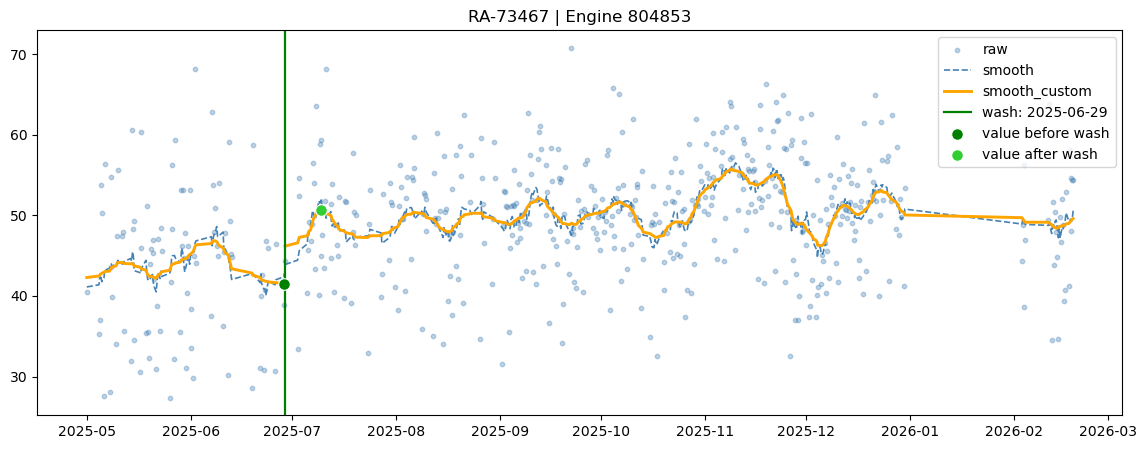

In [2]:
import matplotlib.pyplot as plt

# Specific maintenance event to inspect
target_aircraft = "RA-73467"
target_engine_id = "804853"

flights = [
    FlightRecord(
        engine_id=row.engine_id, 
        parameter_name="EGTHDM", float_value=row.egthdm,
        flight_datetime=row.flight_datetime, flight_phase=FlightPhase.TAKEOFF,
    )
    for row in takeoff.query('engine_id == @target_engine_id').itertuples()
]
maint_ = maintenance.query("ata_code == '331' and engine_id == @target_engine_id and maint_datetime >= '2025-06-28' and maint_datetime <= '2025-06-30'")
ev = maint_.iloc[0]

maint_records = [
    MaintenanceRecord(
        engine_id=ev.engine_id,
        maint_datetime=pd.to_datetime(ev.maint_datetime),
        ata_code=ev.ata_code
    )
]

wash_plot = calc.build_plot(flights=flights, maintenances=maint_records, parameter=EGTHDM)


markers = wash_plot.markers[0]

fig, ax = plt.subplots(figsize=(14, 5))

for curve in wash_plot.curves:
    dates = [pt.flight_datetime for pt in curve.points]
    points = [pt.value for pt in curve.points]
    if curve.kind == "smooth":
        ax.plot(
            dates, points, 
            color="steelblue", linewidth=1.2, linestyle="--", label="smooth",
        )
    elif curve.kind == "smooth_custom":
        ax.plot(
            dates, points, 
            color="orange", linewidth=2.1, label="smooth_custom",
        )
    elif curve.kind == "raw":
        ax.scatter(
            dates, points, 
            s=10, color="steelblue", alpha=0.35, label="raw",
        )

marker = wash_plot.markers[0]

ax.axvline(marker.wash_event_point.flight_datetime, color="green", linewidth=1.6, label=f"wash: {pd.to_datetime(ev.maint_datetime).date()}")
if marker.loss_of_efficiency_point is not None:
    ax.axvline(marker.loss_of_efficiency_point.flight_datetime, color="red", linestyle="--", linewidth=1.6, label=f"loss of efficiency: {marker.loss_of_efficiency_point.flight_datetime.date()}")

ax.scatter(
    [marker.before_value_point.flight_datetime],
    [marker.before_value_point.value],
    marker="o", s=70, color="green", edgecolor="white", linewidth=0.8, zorder=5, label="value before wash",
)
ax.scatter(
    [marker.after_value_point.flight_datetime],
    [marker.after_value_point.value],
    marker="o", s=70, color="limegreen", edgecolor="white", linewidth=0.8, zorder=5, label="value after wash",
)

ax.set_title(f"{target_aircraft} | Engine {target_engine_id}")

plt.legend()
plt.show()